# Ligh waves part 2
## The Jamin interferometer
In this experiment, you will buid the Jamin interferometer as illustrated in the following figure. **The primary goal is to examine the relationship between the refractive index of a gas and pressure.** In particular, you will measure the polarizability $\alpha$ for air, helium and CO2.

The first prism splits the incoming beam into two beams of approximately equal intensity. One beam will pass through air while the other will pass through a vacuum tube, allowing you to control the pressure with a vacuum pump. The second prism reflects the two beams onto a CCD camera. When the setup is properly aligned, an interference pattern will be visible between the two beams. An example of the interference pattern between the two beams as seen on the CCD camera is provided in the image below.

## Tips for aligning the optical setup

* **Ensure your telescope is collimated**: This means that the two lenses placed after the laser maintain the same beam shape for the relevant distances in your experiment. If not, adjust the distance between the two lenses until the beam retains the same size for distances up to 1.5m.

* **Start alignment without the vacuum tube**: First position the prisms and the camera. Make sure that both beams coincide on the camera on the same position. After you confirm that, introduce the vacuum tube.

* **Beam quality is crucial for observing the interference pattern**: If the beam shape is distorted or contains artifacts, it will be difficult to observe the interference. Take care to ensure that the beam shape is not compromised by any optical element and that it is not cropped at any point on its path. If any optical element has minor imperfections such as scratches or dirt, try to avoid directing the beam onto these imperfections.





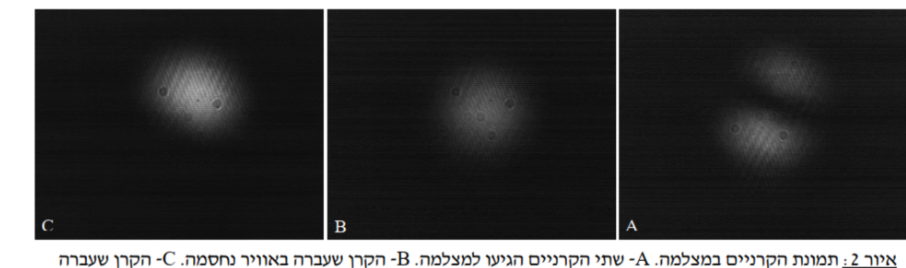

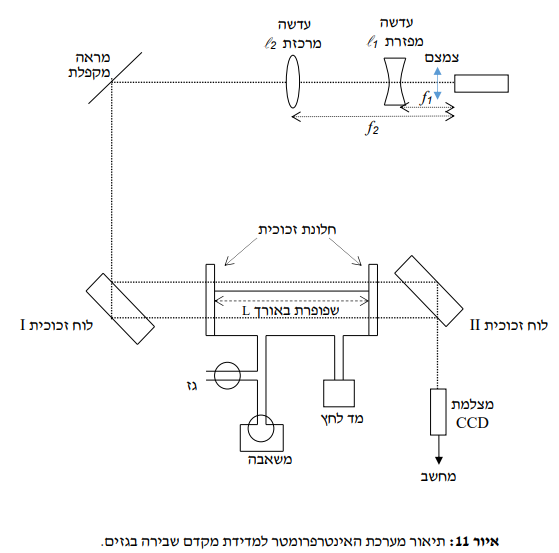

In [5]:
from scipy.constants import Boltzmann, mmHg, zero_Celsius # Some constants we are going to use
import numpy as np 				# math functions
import matplotlib.pyplot as plt 			# for plotting figures and setting their properties
from scipy.stats import linregress 		# contains linregress (for linear regression)


gas: air
Pressures: [ 26  32  39  46  54  62  69  76  86  94 104 113 121 129 137 144 153 161
 169 175 200 223 247 270 293 357 421 501 583 661 738 816 899 981]
Fringes:   [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  22  25  28  31  34  41  48  57  66  75  84  93 102 111]
Total measurements: 34
Slope:         8.7020
Intercept:     7.1493
R²:            0.9997
Reduced Chi²:  1.2110


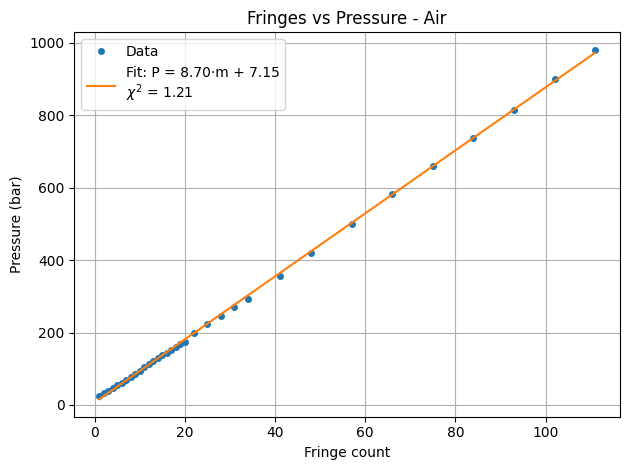

gas: $\text{CO}_2$
Pressures: [ 37  92 141 192 244 295 348 401 452 505 559 612 665 717 767 819 871 925
 979]
Fringes:   [  1  10  19  28  37  46  55  64  73  82  91 100 109 118 127 136 145 154
 163]
Total measurements: 19
Slope:         5.8084
Intercept:     30.0811
R²:            1.0000
Reduced Chi²:  0.1734


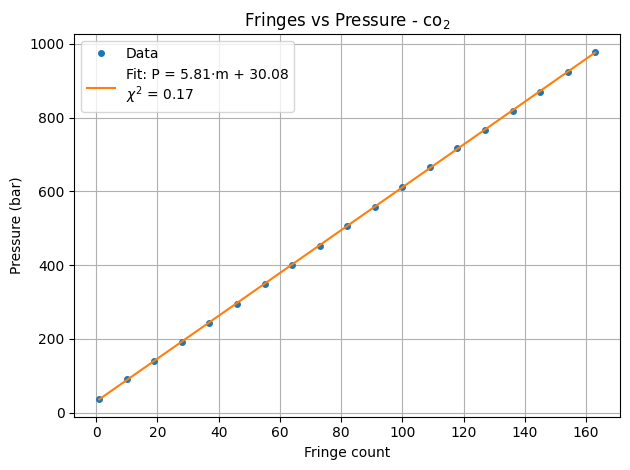

gas: helium
Pressures: [  35   73  117  162  213  267  319  360  406  453  500  550  602  655
  703  753  804  853  904  959 1012]
Fringes:   [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Total measurements: 21
Slope:         49.0429
Intercept:     -29.9476
R²:            0.9995
Reduced Chi²:  2.8086


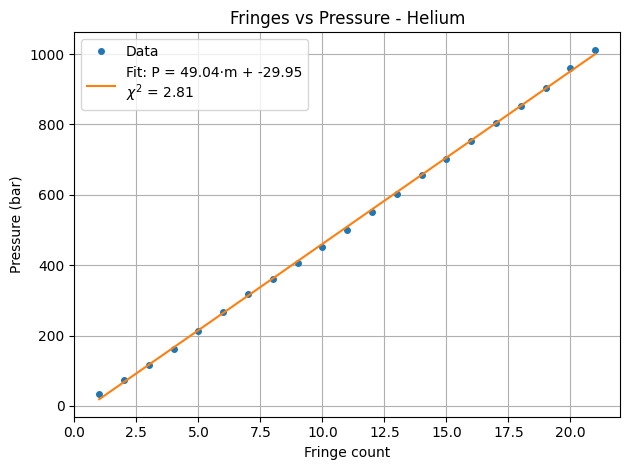

In [67]:
import numpy as np
import re
import os

def plot_gas_data(path, sigma, gas=''):
    gas = gas or os.path.splitext(path)[0]
    pressures = []
    fringes = []
    fringe = 0

    with open(path) as f:
        lines = [l.rstrip("") for l in f if l.strip()]

    for line in lines:
        if re.fullmatch(r"-+(\*\d+)?(\n)?", line):
            dashes = len(re.match(r"-+", line).group())
            mult_match = re.search(r"\*(\d+)", line)
            multiplier = int(mult_match.group(1)) - 7 if mult_match else 1
            fringe += dashes * multiplier - 1  # -1 because the next measurement adds 1
        else:
            fringe += 1
            pressures.append(int(line))
            fringes.append(fringe)

    pressures = np.array(pressures)
    fringes = np.array(fringes)

    print(f"gas: {gas}")
    print("Pressures:", pressures)
    print("Fringes:  ", fringes)
    print(f"Total measurements: {len(pressures)}")

    # Linear regression: pressure as a function of fringe count
    slope, intercept, r_value, p_value, std_err = linregress(fringes, pressures)
    fit_line = slope * fringes + intercept

    # Reduced chi-squared
    dof = len(pressures) - 2  # 2 fitted parameters
    reduced_chi2 = np.sum(((pressures - fit_line) / sigma) ** 2) / dof

    print(f"Slope:         {slope:.4f}")
    print(f"Intercept:     {intercept:.4f}")
    print(f"R²:            {r_value**2:.4f}")
    print(f"Reduced Chi²:  {reduced_chi2:.4f}")

    fig, ax = plt.subplots()

    ax.plot(fringes, pressures, 'o', markersize=4, label='Data')
    ax.plot(fringes, fit_line, '-', label=(
        f'Fit: P = {slope:.2f}·m + {intercept:.2f}\n'
        fr'$\chi^2$ = {reduced_chi2:.2f}'
    ))
    ax.set_xlabel('Fringe count')
    ax.set_ylabel('Pressure (bar)')
    ax.set_title(f'Fringes vs Pressure - {gas.capitalize()}')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_gas_data("air.txt", 4)
plot_gas_data("co2.txt", 4, gas=r'$\text{CO}_2$')
plot_gas_data("helium.txt", 4)
